In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import seaborn as sns
import numpy as np

In [12]:
daily_weather = pd.read_csv("../../data/01-interim/Weather/CLEANED_CentralPark_Weather2023.csv")
daily_ridership = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Daily_Manhattan_Totals.csv")

In [13]:
daily_weather = daily_weather.drop(['Station','Name','Latitude','Longitude','Snow','Snow?', 'Precipitation', 'Rain?'], axis = 1)

In [14]:
#to be continued....
#model = sm.OLS(daily_ridership['ridership'], daily_weather['Avg_Temp']).fit()
#model.summary()

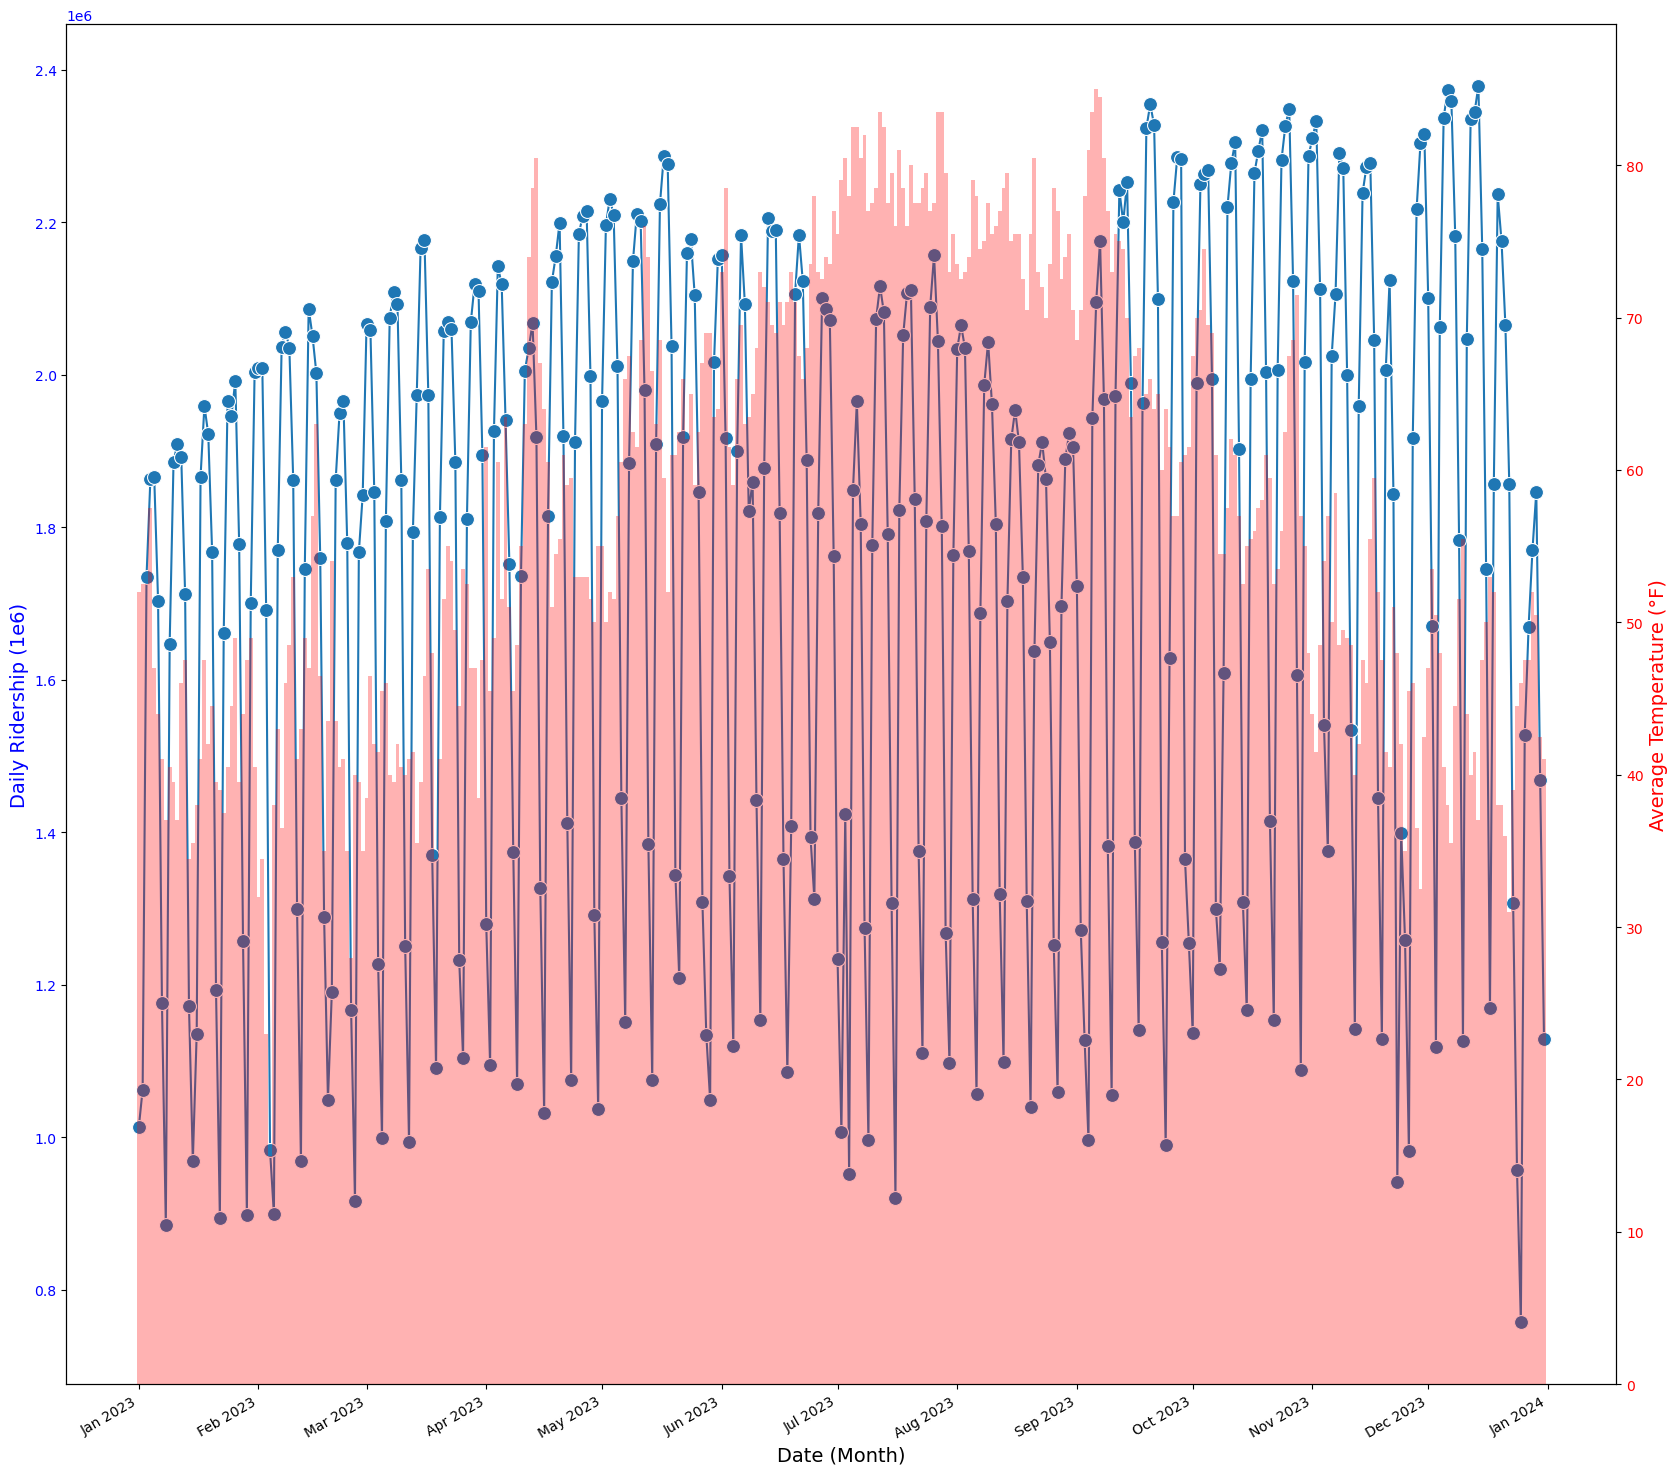

In [35]:
#ik this is messy af but this is my kid and i love her
daily_weather['Date'] = pd.to_datetime(daily_weather['Date'])
daily_ridership['date'] = pd.to_datetime(daily_ridership['date'])

fig, ax = plt.subplots()
fig.set_figheight(20)
fig.set_figwidth(20)
sns.lineplot(x = 'date', y = 'ridership', data = daily_ridership, ax = ax, marker = 'o', markersize = 10)
ax2 = ax.twinx()
ax2.bar(daily_weather['Date'], daily_weather['Avg_Temp'],color = 'red', alpha = 0.3, width = 1.0)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_xlabel('Date (Month)', fontsize = 14)
ax.set_ylabel('Daily Ridership (1e6)', color='blue', fontsize=14)
ax.tick_params(axis='y', labelcolor='blue')
ax2.set_ylabel('Average Temperature (°F)', color = 'red', fontsize = 14)
ax2.tick_params(axis='y', labelcolor='red')

fig.autofmt_xdate()

#errorbar graveyard
#y_err = np.array(daily_weather[['Min_Temp', 'Max_Temp']])
#ax.errorbar(x = daily_weather['Date'], y = daily_weather['Avg_Temp'], yerr = y_err, fmt = 'none')


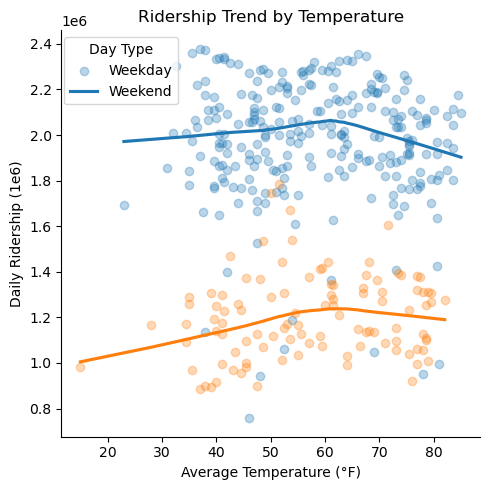

In [60]:
#ridership and average temperature threshold (visual)
daily_ridership['is_weekend'] = daily_ridership['date'].dt.dayofweek > 4
merged = daily_ridership.merge(daily_weather, left_on='date', right_on='Date')
sns.lmplot(x='Avg_Temp', y='ridership', data=merged, hue='is_weekend', lowess = True, scatter_kws={'alpha':0.3}, legend = False)
plt.legend(title = 'Day Type', labels = ['Weekday','Weekend'], loc = 'upper left', bbox_to_anchor=(-0.01, 1))
plt.title('Ridership Trend by Temperature')
plt.xlabel('Average Temperature (°F)')
plt.ylabel('Daily Ridership (1e6)')
plt.subplots_adjust(right=0.8)
plt.tight_layout()


In [61]:
#ridership and average temperature threshold (mathematical)
def find_peak(data):
    z = np.polyfit(data['Avg_Temp'], data['ridership'], 2)
    p = np.poly1d(z)
    
    peak_temp = -z[1] / (2 * z[0])
    return peak_temp

weekday_peak = find_peak(merged[merged['is_weekend'] == False])
weekend_peak = find_peak(merged[merged['is_weekend'] == True])

print(f"Weekday Ridership peaks at: {weekday_peak:.1f}°")
print(f"Weekend Ridership peaks at: {weekend_peak:.1f}°")

Weekday Ridership peaks at: 55.3°
Weekend Ridership peaks at: 61.9°
